# Introduction to EMagPy

---

## Overview

**EMagPy** is a Python package for processing and inverting EMI data. It provides
both a **standalone graphical user interface (GUI)** and a **Python API** designed
for use in Jupyter notebooks. The main class is `Problem`.

```{note} Learning Objectives

By the end of this notebook you will be able to:

- Install EMagPy and import the `Problem` class
- Load field data and inspect the CSV format
- Visualise ECa profiles and maps
- Define a starting model and run a 1D inversion
- Visualise inverted conductivity depth profiles and slices
```

> **Citation:** McLachlan P., Blanchy G. and Binley A. 2021.
> *EMagPy: Open-source, platform-independent processing and inversion of electromagnetic induction data.*
> Computers & Geosciences, 146, 104561. <https://doi.org/10.1016/j.cageo.2020.104561>

---

## Installation

EMagPy can be installed in three ways depending on your needs.

#### Option A — Standalone executable (no Python required, recommended for this course)

1. Go to the [EMagPy releases page](https://gitlab.com/hkex/emagpy/-/releases) on GitLab.
2. Download the latest **`EMagPy_x.x.x_windows.zip`**.
3. Extract the zip and double-click **`EMagPy.exe`** to launch the GUI.

```{warning} Windows SmartScreen warning
If you see *"Windows protected your PC"*, click **More info** → **Run anyway**.
The executable is not commercially signed but is safe to use.
```

#### Option B — pip (recommended for scripting and Jupyter)

```bash
pip install emagpy
```

---

## Complete minimal workflow

### 1 Imports

In [1]:
import os
import numpy as np
import pandas as pd
from emagpy import Problem  # main class
testdir = '../../assets/complementary_data/cover-crop/'

### 2 Load data and inspect format

EMagPy imports data from a `.csv` file where **column headers are the coil
configurations** (e.g. `VCP0.71`, `HCP1.48`). Each row is one measurement
location.

In [2]:
k = Problem()                              # create the main object
k.createSurvey(testdir + 'coverCrop.csv') # import the data

Removing 1 NaN from survey


In [3]:
df = pd.read_csv(testdir + 'coverCrop.csv')
df.head()  # inspect the header format

,x,y,elevation,VCP0.32,VCP0.71,VCP1.18,VCP0.32_inph,VCP0.71_inph,VCP1.18_inph,HCP0.32,HCP0.71,HCP1.18,HCP0.32_inph,HCP0.71_inph,HCP1.18_inph
0,0,0,0.0,34.090222,34.67,38.32,1.79,1.90,2.13,33.53,39.77,45.22,2.13,2.27,2.68
1,1,0,0.1,35.350111,36.69,40.16,1.79,1.87,2.13,39.72,43.81,46.76,2.20,2.30,2.72
2,2,0,0.2,36.680000,35.79,39.21,1.81,1.87,2.14,36.10,40.63,45.16,2.14,2.29,2.71
3,3,0,0.3,41.960556,34.26,37.43,1.76,1.30,2.12,35.64,39.47,41.97,2.18,2.22,2.63
4,4,0,0.4,29.250444,28.91,33.51,1.79,1.92,2.19,32.46,36.36,40.58,2.23,2.24,2.69


### 3 Data visualisation

`Problem.show()` plots ECa as a line graph per coil configuration.
If spatial coordinates (`x`, `y`) are present, `Problem.showMap()` produces a
plan-view apparent electrical conductivity (ECa) map.

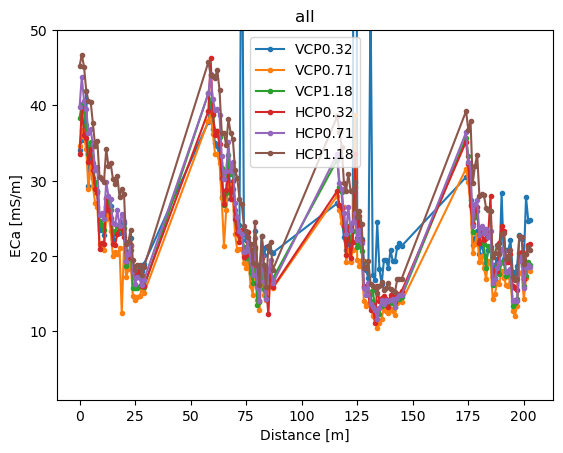

In [4]:
k.show(vmax=50)

concave-hull not installed, will use normal tricontourf instead. Install it with `pip install concave-hull`


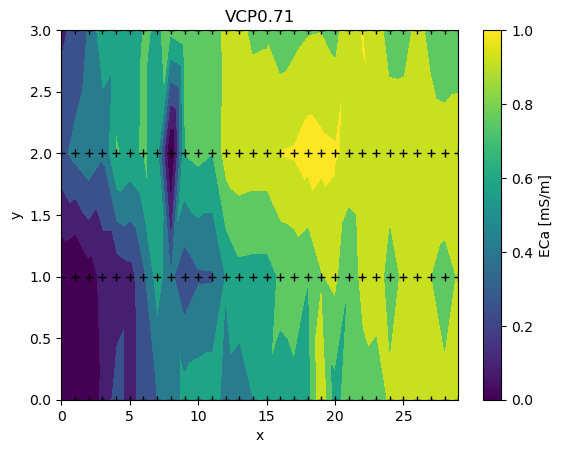

In [5]:
k.showMap(coil='VCP0.71', contour=True, pts=True)

### 4 Starting model

Before inversion, define a layered starting model: the **bottom depth of each
layer** and an initial electrical conductivity value for each layer
(including the half-space below).

In [6]:
k.setInit(
    depths0=[0.5, 1],           # bottom of each layer (m) — last layer is infinite
    conds0=[20, 20, 20],        # starting conductivity (mS/m) per layer
    fixedConds=[False, False, False]
)

### 5 Forward models and solvers

Several forward models are available, trading accuracy for speed:

| Model | Description |
|---|---|
| `CS` | Cumulative Sensitivity (McNeill 1980) — default, fastest |
| `CSgn` | CS with Gauss-Newton solver — uses `invertGN()` automatically |
| `FSlin` | Full Solution (Maxwell) with low induction number (LIN) approximation |
| `FSeq` | Full Solution without LIN — apparent ECa via optimisation (Andrade et al. 2016) |
| `Q` | Full Solution minimising quadrature directly — preferred for ECa > 100 mS/m |

Two families of solvers are available:

- **Gradient-based** (`L-BFGS-B`, `TNC`, `CG`, `Nelder-Mead`) via `scipy.optimize.minimize()`
- **MCMC-based** (`ROPE`, `SCEUA`, `DREAM`) via `spotpy` — suited when layer depths are free parameters

### 6 Inversion

120/120 inverted

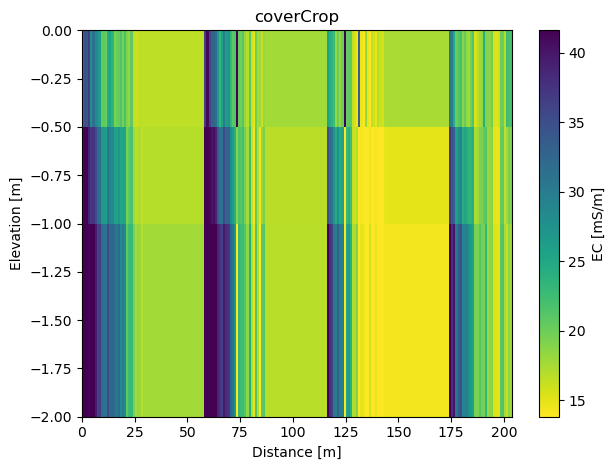

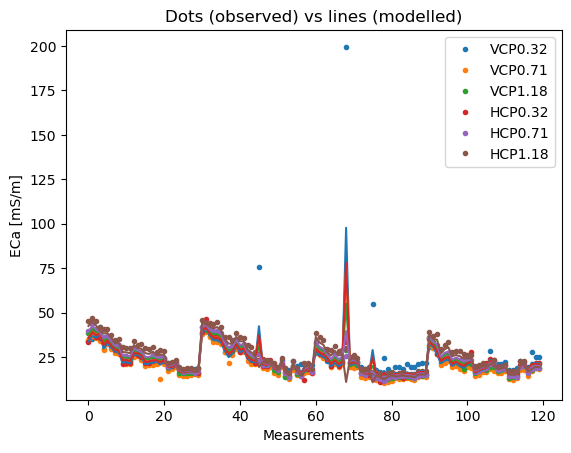

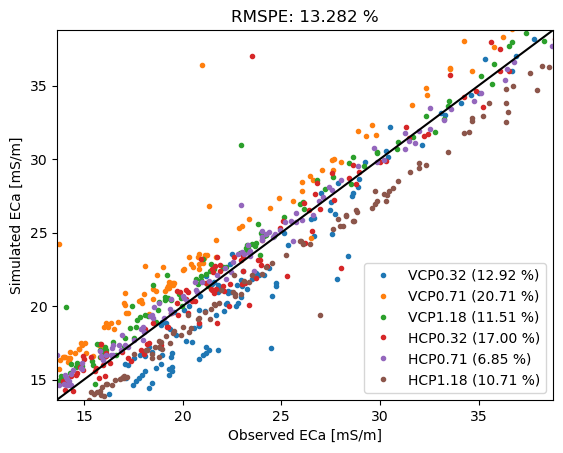

In [7]:
k.invert()       # default: CS forward model, L-BFGS-B solver
k.showResults()  # inverted conductivity depth section
k.showMisfit()   # data misfit per coil
k.showOne2one()  # observed vs predicted ECa

### 7 Depth slices

If spatial coordinates are available, `showSlice()` produces plan-view maps
of conductivity at a given layer index.

concave-hull not installed, will use normal tricontourf instead. Install it with `pip install concave-hull`
concave-hull not installed, will use normal tricontourf instead. Install it with `pip install concave-hull`


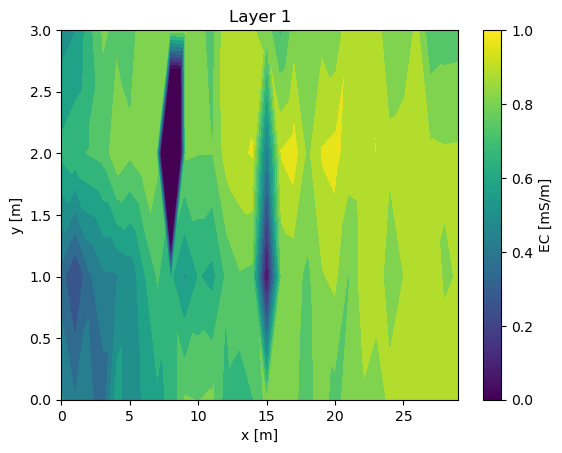

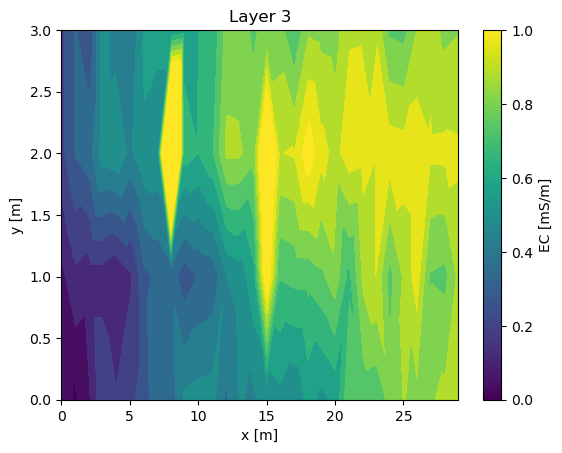

In [8]:
k.showSlice(islice=0, contour=True, vmin=12, vmax=50)  # top layer
k.showSlice(islice=2, contour=True, vmin=12, vmax=50)  # bottom layer

Access the method docstring for all available options:

In [9]:
help(k.showSlice)

Help on method showSlice in module emagpy.Problem:

showSlice(index=0, islice=0, contour=False, vmin=None, vmax=None, cmap='viridis_r', ax=None, pts=False) method of emagpy.Problem.Problem instance
    Show depth slice of EC (if islice > 0) and depth (if islice < 0).
    
    Parameters
    ----------
    index : int, optional
        Survey index. Default is first.
    islice : int, optional
        Layer index (if islice > 0). Default is first layer. If islice < 0,
        the depths will be display instead (e.g. islice = -1 will display
        the depth of the bottom of the first layer).
    contour : bool, optional
        If `True` then there will be contouring.
    vmin : float, optional
        Minimum value for colorscale.
    vmax : float, optional
        Maximum value for colorscale.
    cmap : str, optional
        Name of colormap. Default is viridis_r.
    ax : Matplotlib.Axes, optional
        If specified, the graph will be plotted against it.
    pts : boolean, option

---

## Summary

```{tip} What you have learned

| Step | Method | Purpose |
|------|--------|---------|
| 1 | `Problem()` | Create the main object |
| 2 | `createSurvey(file)` | Load field data |
| 3 | `show()` / `showMap()` | Visualise ECa data |
| 4 | `setInit(depths0, conds0)` | Define starting model |
| 5 | `invert()` | Run 1D inversion |
| 6 | `showResults()` / `showMisfit()` / `showOne2one()` | Assess inversion quality |
| 7 | `showSlice()` | Plan-view conductivity maps |

**Next notebook:** [ERT Processing with ResIPy](nb_resipy.md) — process **electrical resistivity tomography** data with ResIPy.
```

---

## Additional Resources

- [EMagPy official documentation](https://hkex.gitlab.io/emagpy/)
- [EMagPy GitLab repository](https://gitlab.com/hkex/emagpy)
- [EMagPy on PyPI](https://pypi.org/project/emagpy/)